<div align="center">

# 3º PROJETO

| Disciplina | Semestre | Docente | Horário |
| :---: | :---: | :---: | :---: |
| PAM0466 - SISTEMAS INTELIGENTES | 2026.1 | PEDRO THIAGO VALÉRIO DE SOUZA | 3M23 4M45 |

| Discente | Matrícula |
| :---: | :---: |
| ELTON CAIO VIEIRA DE LIMA | 2020010673 |
| LUCAS VIERES ARAÚJO FARIAS | 2025022531 |

</div>

## ATIVIDADES

1. Preparação dos dados: carregue o dataset e recodifique a variável quality em três classes: notas ≤5 como *ruim*, 6–7 como *médio* e ≥8 como *bom*. Em seguida, normalize todos os atributos utilizando Min-Max ou Z-score. Justifique por que a normalização é uma etapa obrigatória para o 𝑘-NN.

Dataset utilizado:

In [1]:
import pandas as pd

dataset = pd.read_csv("dataset/winequality-red.csv", sep=';')

In [2]:
dataset["quality"] = pd.to_numeric(dataset["quality"], errors='coerce')

def categorizar(qualidade):
    if qualidade <= 5:
        return "ruim"
    elif 5 < qualidade <= 7:
        return "medio"
    else:
        return "bom"

dataset["quality"] = dataset["quality"].apply(categorizar)
print(dataset["quality"].value_counts())

quality
medio    837
ruim     744
bom       18
Name: count, dtype: int64


In [3]:
X = dataset.drop("quality", axis=1)
y = dataset["quality"]

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


A normazilação é fundamental em modelos *k-NN*, pois o mesmo utiliza de medidas de distância para classificação dos dados. E alguns dataset podem apresentar features com escalas muito altas e que podem ter uma influência muito superior do que outras no calculo da distância, e a normalização faz com que todas as features fiquem no mesmo patamar de influência nesse quesito, fazendo com que o modelo tenha um desempenho muito melhor.

<hr>

2. Divisão treino/teste: divida os dados em 80% para treino e 20% para teste, utilizando divisão estratificada para garantir que a proporção das três classes seja mantida em ambos os conjuntos.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 1279 amostras
Teste:  320 amostras


A função *stratify* é interessante de ser usada, pois faz com que a proporção das classes seja igual no treinamento e no teste, evitando avaliações distorcidas do modelo.

<hr>

3. Treinamento e escolha do 𝑘: treine o modelo para diferentes valores de (ex: 1, 3, 5, 7, 11) utilizando validação cruzada de 5 *folds* sobre o conjunto de treino. Plote a acurácia média em função de 𝑘 e escolha o valor com melhor desempenho. O que acontece com o modelo para valores muito baixos e muito altos de 𝑘?

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = [1, 5, 10, 13, 17]
mean_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    
    mean_accuracies.append(scores.mean())
    
    print(f"k={k} -> Acurácia média: {scores.mean():.4f}")

k=1 -> Acurácia média: 0.7170
k=5 -> Acurácia média: 0.6810
k=10 -> Acurácia média: 0.6826
k=13 -> Acurácia média: 0.7068
k=17 -> Acurácia média: 0.7178


Plot do gráfico dos valores de *k*.

/home/pc/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


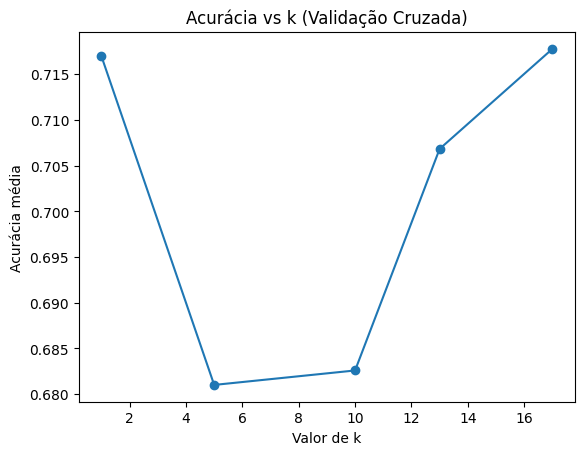

In [7]:
import matplotlib.pyplot as plt

plt.plot(k_values, mean_accuracies, marker='o')
plt.xlabel("Valor de k")
plt.ylabel("Acurácia média")
plt.title("Acurácia vs k (Validação Cruzada)")
plt.show()

Dos valores utilizados como base para a validação cruzada, o *k* com melhor desempenho foi o *k*=17, embora ele ganhe por uma diferença de 0.0008% de *k*=1, ele possui um desempenho melhor, pois situações onde temos um *k*=1 podem indicar um *overfitting* do modelo, pois eles são muito sensíveis a ruídos nos dados, e valores maiores para *k* (como o *k*=17) podem representar generalizações maiores, estabilizando o modelo. Porém, deve-se tomar cuidado com valores de *k* muito altos, pois eles podem levar ao *underfitting*, já que o modelo passa a considerar muitos vizinhos, se tornando excessivamente generalista.

<hr>

4. Avaliação do modelo: utilizando o conjunto de teste — reservado exclusivamente para esta etapa — calcule a matriz de confusão e as métricas de acurácia, precisão, *recall* e F1-score para cada classe. Responda: Entre quais classes o modelo erra com mais frequência?

In [8]:
from sklearn.neighbors import KNeighborsClassifier

modelo_final = KNeighborsClassifier(n_neighbors=17)
modelo_final.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=17)

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = modelo_final.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")

print(classification_report(y_test, y_pred))

[[  0   4   0]
 [  0 141  26]
 [  0  36 113]]
Acurácia: 0.7937
              precision    recall  f1-score   support

         bom       0.00      0.00      0.00         4
       medio       0.78      0.84      0.81       167
        ruim       0.81      0.76      0.78       149

    accuracy                           0.79       320
   macro avg       0.53      0.53      0.53       320
weighted avg       0.79      0.79      0.79       320



/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Analisando a matriz de confusão, é possivel observar que o modelo erra, sobretudo, nas classes "médio" e "ruim". Além disso, a classe "bom" apresenta um péssimo desempenho, nao sendo identificada de forma corretamente, mesmo quando o valor de *k* é variado (foram realizados testes com valores de *k*= 1, 11 e 17), indicando que o modelo possui dificuldade com classes menos representadas no modelo, e que somente com o k=1, que foi identificada 1 amostra como "bom".